# Tutorial: Phase 1 EDA Dataset Overview

Audience:
- Semester project teams building the classical ML baseline for skin-condition classification.

Prerequisites:
- Basic Python, NumPy, pandas, and image handling with OpenCV.

Objective:
- Inspect dataset structure, class balance, image sizes, sample images, and skipped files before feature engineering.


## Outline

1. Setup and reproducibility
2. Discover dataset records
3. Inspect class distribution
4. Review image size statistics with a bounded scan
5. Visualize sample images by class
6. Note dataset risks before modeling


In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 140)
SEED = 42


/Users/vaishnavverma/.matplotlib is not a writable directory


Matplotlib created a temporary cache directory at /var/folders/gp/0qsbr0x11d315dt15fl17c940000gn/T/matplotlib-0p1oyc1a because there was an issue with the default path (/Users/vaishnavverma/.matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


Matplotlib is building the font cache; this may take a moment.


In [2]:
CANDIDATE_DATA_DIRS = [
    PROJECT_ROOT / 'dataset',
    PROJECT_ROOT / 'data' / 'raw' / 'Multi-Class Skin Condition Image Dataset (MSC-6)',
]
DATA_DIR = next((path for path in CANDIDATE_DATA_DIRS if path.exists()), CANDIDATE_DATA_DIRS[0])
CANDIDATE_OUTPUT_DIRS = [
    PROJECT_ROOT / 'outputs' / 'phase1_baseline_msc6',
    PROJECT_ROOT / 'outputs' / 'phase1_baseline',
]
OUTPUT_DIR = next((path for path in CANDIDATE_OUTPUT_DIRS if path.exists()), CANDIDATE_OUTPUT_DIRS[0])
IMAGE_SIZE = (224, 224)
TEST_SIZE = 0.2
RANDOM_STATE = 42
SAMPLE_FEATURE_ROWS = 64
SIZE_SCAN_LIMIT = 1000
print('Using DATA_DIR:', DATA_DIR)
print('Using OUTPUT_DIR:', OUTPUT_DIR)

from src.skin_analysis.data import discover_dataset_records, load_and_preprocess_image


Using DATA_DIR: /Users/vaishnavverma/Downloads/Hybrid-Dermatologist/data/raw/Multi-Class Skin Condition Image Dataset (MSC-6)
Using OUTPUT_DIR: /Users/vaishnavverma/Downloads/Hybrid-Dermatologist/outputs/phase1_baseline_msc6


In [3]:
records_df, skipped_df, label_mapping = discover_dataset_records(DATA_DIR)
print(f'Discovered image files: {len(records_df)}')
print(f'Discovery skips: {len(skipped_df)}')
display(records_df.head())
if not skipped_df.empty:
    display(skipped_df.head())


Discovered image files: 8823
Discovery skips: 0


,path,label,display_label
0,/Users/vaishnavverma/Downloads/Hybrid-Dermatol...,normal,normal
1,/Users/vaishnavverma/Downloads/Hybrid-Dermatol...,normal,normal
2,/Users/vaishnavverma/Downloads/Hybrid-Dermatol...,normal,normal
3,/Users/vaishnavverma/Downloads/Hybrid-Dermatol...,normal,normal
4,/Users/vaishnavverma/Downloads/Hybrid-Dermatol...,normal,normal


,class_name,image_count
0,eczema,3133
1,normal,1240
2,acne,1185
3,rosacea,1108
4,wrinkles,1100
5,dark spots,1057


/var/folders/gp/0qsbr0x11d315dt15fl17c940000gn/T/ipykernel_51528/4092654504.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=class_counts, x='class_name', y='image_count', palette='crest')


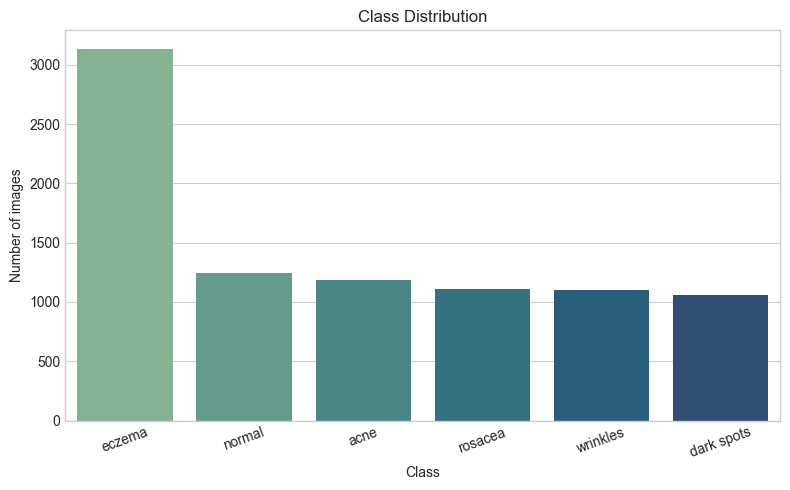

In [4]:
class_counts = (
    records_df['display_label']
    .value_counts()
    .rename_axis('class_name')
    .reset_index(name='image_count')
)
display(class_counts)

plt.figure(figsize=(8, 5))
sns.barplot(data=class_counts, x='class_name', y='image_count', palette='crest')
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Number of images')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


Scanned image sizes for 1000 files


,original_width,original_height
count,1000.00,1000.00
mean,814.30,937.21
std,1131.56,1420.16
min,80.00,51.00
25%,224.00,224.00
50%,224.00,224.00
75%,640.00,640.00
max,4624.00,4624.00


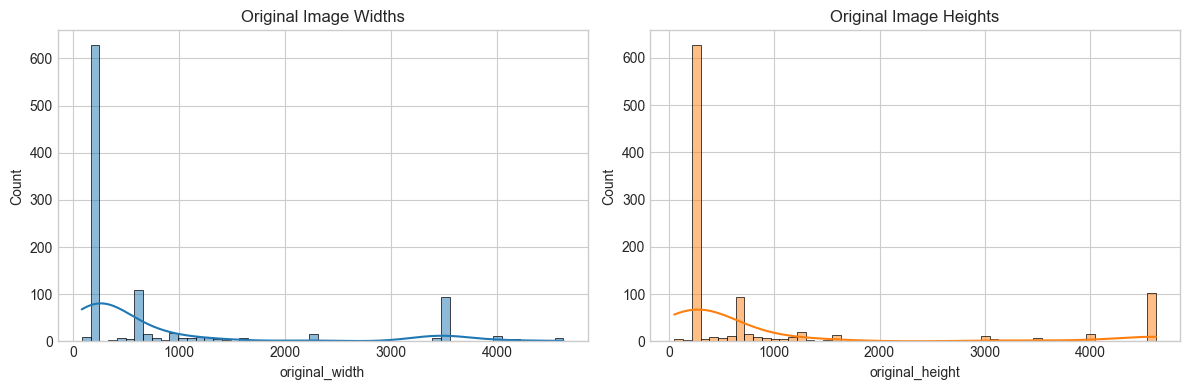

In [5]:
size_records = []
for row in records_df.head(SIZE_SCAN_LIMIT).itertuples(index=False):
    loaded = load_and_preprocess_image(row.path, image_size=IMAGE_SIZE)
    if loaded is None:
        continue
    _, original_size = loaded
    size_records.append({'original_width': original_size[0], 'original_height': original_size[1]})

size_df = pd.DataFrame(size_records)
print(f'Scanned image sizes for {len(size_df)} files')
display(size_df.describe().round(2))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(size_df['original_width'], kde=True, ax=axes[0], color='#1f77b4')
axes[0].set_title('Original Image Widths')
sns.histplot(size_df['original_height'], kde=True, ax=axes[1], color='#ff7f0e')
axes[1].set_title('Original Image Heights')
plt.tight_layout()
plt.show()


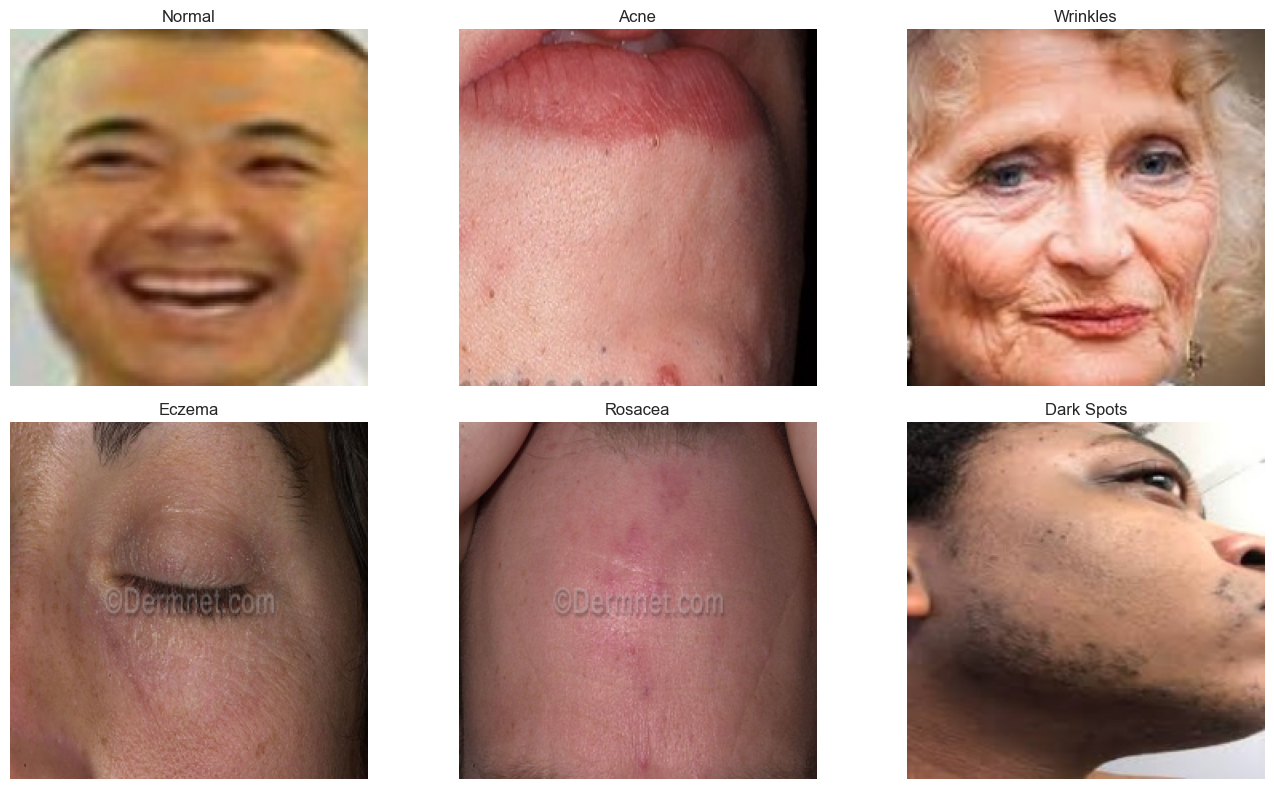

In [6]:
example_rows = records_df.groupby('display_label', sort=True).head(1).reset_index(drop=True)
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for ax, row in zip(axes, example_rows.itertuples(index=False)):
    loaded = load_and_preprocess_image(row.path, image_size=IMAGE_SIZE)
    if loaded is None:
        ax.axis('off')
        continue
    image_bgr, _ = loaded
    image_rgb = cv2.cvtColor((image_bgr * 255).astype(np.uint8), cv2.COLOR_BGR2RGB)
    ax.imshow(image_rgb)
    ax.set_title(row.display_label.title())
    ax.axis('off')

for ax in axes[len(example_rows):]:
    ax.axis('off')

plt.tight_layout()
plt.show()


## Notes

- This notebook scans metadata first so it stays practical on larger datasets such as MSC-6.
- Increase `SIZE_SCAN_LIMIT` if you want full-dataset size statistics.
- The next notebook focuses on handcrafted color and texture features using small, explainable samples.
